In [10]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from tensorflow import keras

In [11]:
# get demand data from NTUST (sum from multiple building in NTUST)
power_df = pd.read_csv("../dataset/NTUST.csv", index_col=0, parse_dates=True)
power_df = power_df.asfreq('h') 
power_df = pd.DataFrame(power_df.loc[power_df.index.year!=2020, "KW"].round(2).copy())

# get weather data from NSRDB (NSRDB.csv), if you want to get data from NASA, use NASA.csv
weather_df = pd.read_csv("../dataset/NSRDB.csv")
weather_df.index = power_df.index 

In [12]:
# select which weather features will be used
col_weather = ['TEMPERATURE', 'DEW_POINT', 'RELATIVE HUMIDITY', 'GHI']

# concatenate demand data with weather data
df = pd.concat([power_df, weather_df[col_weather]], axis=1)
col_selected = df.columns

In [13]:
def multivariate_multioutput_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])

    return np.array(data)[:,:,:,np.newaxis,np.newaxis], np.array(labels)[:,:,:,np.newaxis,np.newaxis]


In [14]:
JUDUL = 'GHI5'

In [15]:
# ─────────────── CONFIG ───────────────
TARGET      = 'GHI'          # 'KW' | 'TEMPERATURE' | 'GHI'
HISTORY     = 24            # look-back window
PRED_LEN    = 1             # 1-hour forecrrrrrgerkgerkgerpokgpreogkdddd
BATCH_SIZE  = 32
EPOCHS      = 10
# ───────────────────────────────────────

# ---------- 1 ◇ Mask kalender ----------
is_m = power_df.index.month

def last24(month_num):
    rows = df[is_m == month_num]
    last_ts  = rows.index.max()
    first_ts = last_ts - pd.Timedelta(hours=23)
    return (df.index >= first_ts) & (df.index <= last_ts)

jun_ctx = last24(6)     # 24h 30-Jun
jul_ctx = last24(7)     # 24h 31-Jul

train_mask = (is_m.isin([4,5,6])) & (~jun_ctx)
val_mask   = jun_ctx | (is_m == 7)
test_mask  = jul_ctx | (is_m == 8)

train_df = df.loc[train_mask]
val_df   = df.loc[val_mask]
test_df  = df.loc[test_mask]

# ---------- 2 ◇ Scaling ----------------
scaler_x = StandardScaler().fit(train_df)               # 3 fitur
scaler_y = StandardScaler().fit(train_df[[TARGET]])     # fitur target saja

def scale_xy(frame):
    X = scaler_x.transform(frame)
    y = scaler_y.transform(frame[[TARGET]])
    return X, y

# ---------- 3 ◇ Buat sequence ----------
def build_set(frame):
    X, y = scale_xy(frame)
    Xs, ys = multivariate_multioutput_data(
        dataset=X, 
        target=y, 
        start_index=0, end_index=None,
        history_size=HISTORY, target_size=PRED_LEN,
        step=1, single_step=False
    )
    # 5D → 3D  (samples, steps, features)
    Xs = Xs.reshape(-1, HISTORY, X.shape[1])      # in_feature = 3
    ys = ys.reshape(-1, PRED_LEN, 1)              # out_feature = 1
    return Xs, ys

X_train, y_train = build_set(train_df)
X_val,   y_val   = build_set(val_df)
X_test,  y_test  = build_set(test_df)

print("train:", X_train.shape, y_train.shape)
print("val  :", X_val.shape,   y_val.shape)
print("test :", X_test.shape,  y_test.shape)

# ---------- 4 ◇ Model -------------------
def model_lstm(n_shape, n_feature_in, n_feature_out=1,
               n_output=1, n_hidden=512,
               s_activation='tanh', s_recurrent_activation='sigmoid',
               s_learning_rate=0.001):
    
    m  = keras.models.Sequential()
    inp = keras.layers.Input(shape=(n_shape, n_feature_in), name='inp')
    x   = keras.layers.LSTM(units=n_hidden, 
                                  activation=s_activation,
                                  recurrent_activation=s_recurrent_activation,
                                  name='hidden', 
                                  dropout=0.0,
                                  recurrent_dropout=0.0,
                                  return_sequences=True,
                                  )(inp)
    x   = keras.layers.LSTM(n_hidden//2)(x)
    x   = keras.layers.Dense(n_output*n_feature_out)(x)
    out = keras.layers.Reshape([n_output, n_feature_out])(x)

    m   = keras.Model(inp, out)
    m.compile(
        loss='mse',
        optimizer=keras.optimizers.Nadam(learning_rate=s_learning_rate),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae'),
                 keras.metrics.MeanSquaredError(name='mse')]
    )
    return m

model = model_lstm(
    n_shape=HISTORY,
    n_feature_in=X_train.shape[2],   # 3
    n_feature_out=1,                 # target only
    n_output=PRED_LEN
)

cb = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=cb,
    verbose=2
)

# ---------- 5 ◇ Prediksi & metrik -------
y_pred_s = model.predict(X_test, verbose=0)
print(f"[scaled] mean_pred={y_pred_s.mean():.4f}  "
      f"mean_true={y_test.mean():.4f}")

# MAE pada data scaled
mae_scaled = mean_absolute_error(y_test.reshape(-1, 1), y_pred_s.reshape(-1, 1))
mse_scaled = mean_squared_error(y_test.reshape(-1, 1), y_pred_s.reshape(-1, 1))
print(f"MAE (scaled): {mae_scaled}")
print(f"MSE (scaled): {mse_scaled}")

# Transform balik ke real value
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1))
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1))
print(f"[real  ] mean_pred={y_pred.mean():.2f}  "
      f"mean_true={y_true.mean():.2f}")

# MAE dan MSE pada real value
mae_real = mean_absolute_error(y_true, y_pred)
mse_real = mean_squared_error(y_true, y_pred)
print(f"MAE (real): {mae_real}")
print(f"MSE (real): {mse_real}")

# ---------- 6 ◇ CSV Agustus -------------
start_idx = HISTORY + PRED_LEN
ts_full   = test_df.index[start_idx:]
ts_match  = ts_full[:len(y_true)] 
aug_mask  = ts_full.month == 8

print("timestamp shape: ", ts_full.shape)
print("y_true shape   : ", y_true.shape)
print("y_pred shape   : ", y_pred.shape)
csv_df = pd.DataFrame({
    'timestamp': ts_full[aug_mask],
    f'{TARGET}_true': y_true[aug_mask].ravel(),
    f'{TARGET}_pred': y_pred[aug_mask].ravel()
})
csv_df.to_csv(f'pred_vs_true_{JUDUL}_august.csv', index=False)
print(f"✔  pred_vs_true_{JUDUL}_august.csv ditulis.")


train: (2135, 24, 5) (2135, 1, 1)
val  : (743, 24, 5) (743, 1, 1)
test : (743, 24, 5) (743, 1, 1)
Epoch 1/10
67/67 - 18s - 276ms/step - loss: 0.3364 - mae: 0.3960 - mse: 0.3364 - val_loss: 0.2905 - val_mae: 0.3967 - val_mse: 0.2905
Epoch 2/10
67/67 - 13s - 200ms/step - loss: 0.1796 - mae: 0.2823 - mse: 0.1796 - val_loss: 0.2517 - val_mae: 0.3429 - val_mse: 0.2517
Epoch 3/10
67/67 - 14s - 206ms/step - loss: 0.1547 - mae: 0.2504 - mse: 0.1547 - val_loss: 0.1398 - val_mae: 0.2226 - val_mse: 0.1398
Epoch 4/10
67/67 - 14s - 211ms/step - loss: 0.1432 - mae: 0.2354 - mse: 0.1432 - val_loss: 0.1603 - val_mae: 0.2647 - val_mse: 0.1603
Epoch 5/10
67/67 - 21s - 306ms/step - loss: 0.1442 - mae: 0.2334 - mse: 0.1442 - val_loss: 0.1470 - val_mae: 0.2359 - val_mse: 0.1470
Epoch 6/10
67/67 - 14s - 209ms/step - loss: 0.1390 - mae: 0.2257 - mse: 0.1390 - val_loss: 0.1380 - val_mae: 0.2255 - val_mse: 0.1380
Epoch 7/10
67/67 - 13s - 187ms/step - loss: 0.1386 - mae: 0.2209 - mse: 0.1386 - val_loss: 0.1394 

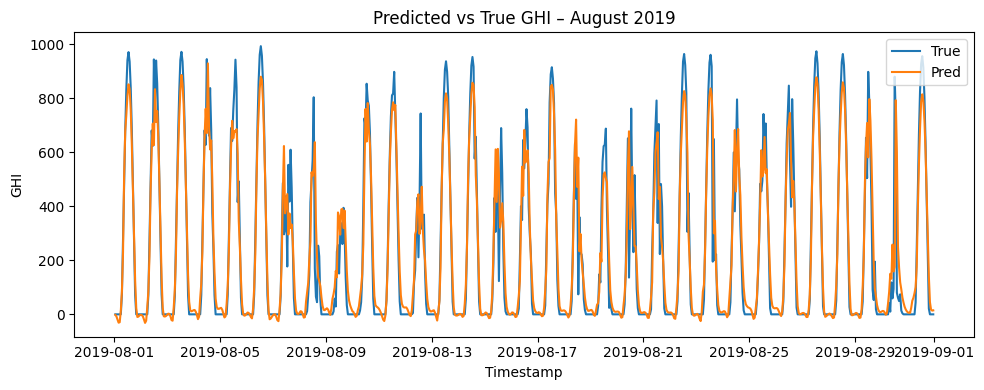

In [16]:
import matplotlib.pyplot as plt

assert len(ts_match) == len(y_true) == len(y_pred)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(ts_match, y_true, label='True')
ax.plot(ts_match, y_pred, label='Pred')
ax.set_xlabel('Timestamp')
ax.set_ylabel(TARGET)
ax.set_title(f'Predicted vs True {TARGET} – August 2019')
ax.legend()
plt.tight_layout()
plt.show()


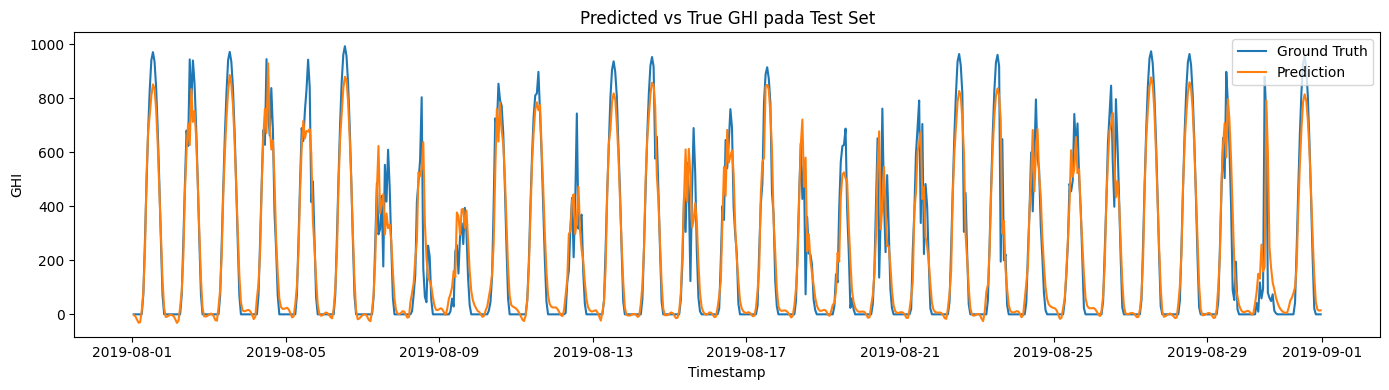

In [17]:
plt.figure(figsize=(14,4))
plt.plot(ts_match, y_true, label='Ground Truth')
plt.plot(ts_match, y_pred, label='Prediction')
plt.xlabel('Timestamp')
plt.ylabel(TARGET)
plt.title('Predicted vs True GHI pada Test Set')
plt.legend()
plt.tight_layout()
plt.show()


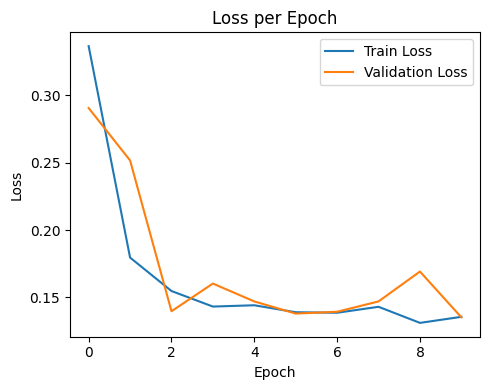

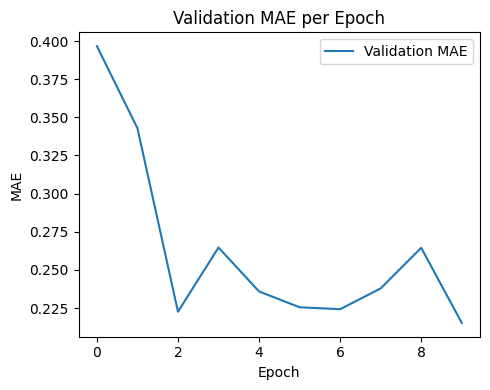

In [18]:
# --- Plot Training Loss & Validation Loss per Epoch ---
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Validation MAE per Epoch ---
plt.figure(figsize=(5,4))
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Validation MAE per Epoch')
plt.legend()
plt.tight_layout()
plt.show()
